<a href="https://colab.research.google.com/github/shivanshi-09/IML_Midterm/blob/main/FNNDiabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

dataset = pd.read_csv("https://raw.githubusercontent.com/shivanshi-09/IML_Midterm/main/nhanes_diabetes_clean.csv")

In [7]:
drop_cols = ["SEQN", "LBXGH", "diabetes_label", "diabetes_binary"]
X = dataset.drop(columns = drop_cols)
y = dataset["diabetes_label"]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [8]:
tier1_cols =[
    "RIDAGEYR", "RIAGENDR", "RIDRETH3", # demographics
    "BMXBMI", "BMXWAIST", # anthropometric
    "BPXSY_mean", "BPXDI_mean" # blood pressure
    ]
tier2_cols = tier1_cols +[
    "LBXTC", "LBXTR", # lipids
    "LBXSCR", # creatinine
    "LBXSATSI", "LBXSASSI", # liver enzymes (ALT, AST)
    "LBXSUA" # uric acid
]
tier3_cols = tier2_cols + [
    "LBXSTP", "LBXSAL", "LBXSCA", # total protein, albumin, calcium
    "LBXSPH", "LBXSNASI", "LBXSKSI", # phosphorus, sodium, potassium
    "LBXSGB", "LBXSBU", "LBXSC3SI"# globulin, BUN, bicarbonate
]
tiers = {
    "Tier 1 (Demographic + Vitals)": tier1_cols,
    "Tier 2 (Liver Measurements)": tier2_cols,
    "Tier 3 (Full Panel)": tier3_cols
}

In [9]:
def one_hot (y, n_classes):
  out = np.zeros((len(y), n_classes))
  out[np.arange(len(y)), y.astype(int)] = 1
  return out

def relu(z):
  return np.maximum(0, z)

def relu_grad(z):
  return (z > 0).astype(int)

def softmax(z):
  z = z- np.max(z, axis = 1, keepdims = True)
  exp = np.exp(z)
  return exp / np.sum(exp, axis = 1, keepdims = True)

def cross_entropy(y_true, y_pred):
  return -np.sum(y_true * np.log(y_pred + 1e-9))/y_true.shape[0]

In [16]:
def init_weights (layer_sizes, seed = 42):
  np.random.seed(seed)
  weights, biases =[], []
  for i in range(len(layer_sizes)-1):
    W = np.random.randn(layer_sizes[i], layer_sizes[i+1])* np.sqrt(2.0/layer_sizes[i])
    b = np.zeros( layer_sizes[i+1])
    weights.append(W)
    biases.append(b)
  return weights, biases

def forward_fnn(X, weights, biases, dropout_rate = 0.0, training = True):
  activations = [X]
  current = X
  for i in range (len(weights)-1):
    z = current @ weights[i] + biases[i]
    a = relu(z)
    if training and dropout_rate > 0:
      mask = (np.random.rand(*a.shape)>dropout_rate)/(1-dropout_rate)
      a = a*mask
    activations.append(a)
    current = a
  z_out = current @ weights[-1] + biases[-1]
  out = softmax(z_out)
  activations.append(out)
  return activations

def backward_fnn(X, Y, activations, weights, biases, alpha):
  n = X.shape[0]
  grad_weights = [None]*len(weights)
  grad_biases = [None]*len(biases)
  delta = activations[-1] - Y
  for i in reversed(range(len(weights))):
    grad_weights[i] = (activations[i].T @ delta)/n
    grad_biases[i] = np.mean(delta, axis = 0)
    if i > 0:
      delta = (delta @ weights[i].T) * (activations[i]>0)
  for i in range(len(weights)):
    weights[i]-= alpha * grad_weights[i]
    biases[i]-=alpha * grad_biases[i]
  return weights, biases

def train_fnn(X_train, Y_train, X_test, Y_test, layer_sizes, alpha = 0.01, dropout = 0.0, epochs = 500, batch_size = None):
  weights, biases = init_weights(layer_sizes)
  train_losses_history, test_losses_history = [], []
  n = X_train.shape[0]
  if batch_size is None:
    batch_size = n
  for epoch in range(epochs):
    idx = np.random.permutation(n)
    X_shuf, Y_shuf = X_train[idx], Y_train[idx]
    for start in range(0, n, batch_size):
      Xb = X_shuf[start:start+batch_size]
      Yb = Y_shuf[start:start+batch_size]
      activations = forward_fnn(Xb, weights, biases, dropout, training = True) # Corrected: Use Xb instead of X_train
      weights, biases = backward_fnn(Xb, Yb, activations, weights, biases, alpha)

    train_acts = forward_fnn(X_train, weights, biases, training=False)
    test_acts  = forward_fnn(X_test,  weights, biases, training=False)
    train_loss = cross_entropy(Y_train, train_acts[-1])
    test_loss  = cross_entropy(Y_test,  test_acts[-1])
    train_losses_history.append(train_loss)
    test_losses_history.append(test_loss)

    if epoch % 50 == 0:
      print(f"Epoch {epoch:4d} | Train Loss: {train_loss:.4f}  Val Loss: {test_loss:.4f}")
  return weights, biases, train_losses_history, test_losses_history

def predict_fnn(X, weights, biases):
  activations = forward_fnn(X, weights, biases, dropout_rate= 0.0, training = False)
  y_probs = activations[-1]
  y_pred = np.argmax(y_probs, axis=1)
  return y_pred, y_probs

In [11]:
def confusion_matrix_counts (y_true, y_pred):
  TP = np.sum((y_true == 1) & (y_pred ==1))
  FP = np.sum((y_true == 0) & (y_pred ==1))
  TN = np.sum((y_true == 0) & (y_pred ==0))
  FN = np.sum((y_true == 1) & (y_pred ==0))
  return TP, FP, TN, FN

def f1_classwise(y_true, y_pred, n_classes):
  results ={}
  for c in range(n_classes):
    y_true_bin = (y_true == c).astype(int)
    y_pred_bin = (y_pred == c).astype(int)
    TP, FP, TN, FN = confusion_matrix_counts(y_true_bin, y_pred_bin)
    precision = TP / (TP + FP+ 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall)
    results [c] = {"f1": f1, "precision": precision, "recall": recall}
  return results


In [12]:
def auroc(y_true, y_prob):
  thresholds = np.linspace(0,1, 1000)
  tprs, fprs = [], []
  for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    TP, FP, TN, FN = confusion_matrix_counts(y_true, y_pred)
    tprs.append(TP/(TP+FN +1e-9))
    fprs.append(FP/(FP+TN +1e-9))
  fprs, tprs = zip(*sorted(zip(fprs, tprs)))
  fprs, tprs = np.array(fprs), np.array(tprs)
  auroc = np.trapezoid(tprs, fprs)
  return auroc, fprs, tprs

In [13]:
def auprc(y_true, y_prob):
    thresholds = np.linspace(0, 1, 1000)
    precisions, recalls = [], []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        TP, FP, TN, FN = confusion_matrix_counts(y_true, y_pred)
        precisions.append(TP / (TP + FP + 1e-9))
        recalls.append(TP / (TP + FN + 1e-9))

    recalls = np.array(recalls)
    precisions = np.array(precisions)

    sorted_idx = np.argsort(recalls)
    recalls = recalls[sorted_idx]
    precisions = precisions[sorted_idx]

    auprc_val = np.trapezoid(precisions, recalls)
    return auprc_val, recalls, precisions


 ------- Tier 1 (Demographic + Vitals) -----------
Epoch    0 | Train Loss: 0.7957  Val Loss: 0.7848
Epoch   50 | Train Loss: 0.7042  Val Loss: 0.7381
Epoch  100 | Train Loss: 0.6791  Val Loss: 0.7531
Epoch  150 | Train Loss: 0.6510  Val Loss: 0.7608
Epoch  200 | Train Loss: 0.6362  Val Loss: 0.7886
Epoch  250 | Train Loss: 0.6045  Val Loss: 0.8073
Epoch    0 | Train Loss: 0.8527  Val Loss: 0.8314
Epoch   50 | Train Loss: 0.7319  Val Loss: 0.7371
Epoch  100 | Train Loss: 0.7188  Val Loss: 0.7353
Epoch  150 | Train Loss: 0.7086  Val Loss: 0.7357
Epoch  200 | Train Loss: 0.6998  Val Loss: 0.7367
Epoch  250 | Train Loss: 0.6922  Val Loss: 0.7425
Epoch    0 | Train Loss: 1.5565  Val Loss: 1.6112
Epoch   50 | Train Loss: 0.8330  Val Loss: 0.8136
Epoch  100 | Train Loss: 0.8001  Val Loss: 0.7812
Epoch  150 | Train Loss: 0.7857  Val Loss: 0.7672
Epoch  200 | Train Loss: 0.7770  Val Loss: 0.7591
Epoch  250 | Train Loss: 0.7711  Val Loss: 0.7539
Epoch    0 | Train Loss: 0.7888  Val Loss: 0.767

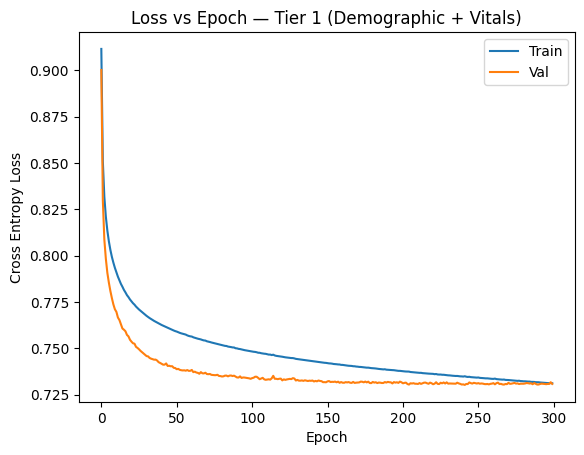

Class 0 (Healthy     ) | F1: 0.8037  AUROC: 0.8187  AUPRC: 0.8768
Class 1 (Prediabetic ) | F1: 0.3966  AUROC: 0.7235  AUPRC: 0.4199
Class 2 (Diabetic    ) | F1: 0.2176  AUROC: 0.8031  AUPRC: 0.3035

 ------- Tier 2 (Liver Measurements) -----------
Epoch    0 | Train Loss: 0.8020  Val Loss: 0.7871
Epoch   50 | Train Loss: 0.6658  Val Loss: 0.7511
Epoch  100 | Train Loss: 0.5918  Val Loss: 0.7724
Epoch  150 | Train Loss: 0.5330  Val Loss: 0.8265
Epoch  200 | Train Loss: 0.4468  Val Loss: 0.9004
Epoch  250 | Train Loss: 0.4487  Val Loss: 1.0170
Epoch    0 | Train Loss: 0.9015  Val Loss: 0.8923
Epoch   50 | Train Loss: 0.7123  Val Loss: 0.7313
Epoch  100 | Train Loss: 0.6873  Val Loss: 0.7304
Epoch  150 | Train Loss: 0.6680  Val Loss: 0.7341
Epoch  200 | Train Loss: 0.6497  Val Loss: 0.7396
Epoch  250 | Train Loss: 0.6317  Val Loss: 0.7427
Epoch    0 | Train Loss: 1.2614  Val Loss: 1.3069
Epoch   50 | Train Loss: 0.8718  Val Loss: 0.8609
Epoch  100 | Train Loss: 0.8209  Val Loss: 0.8060
Ep

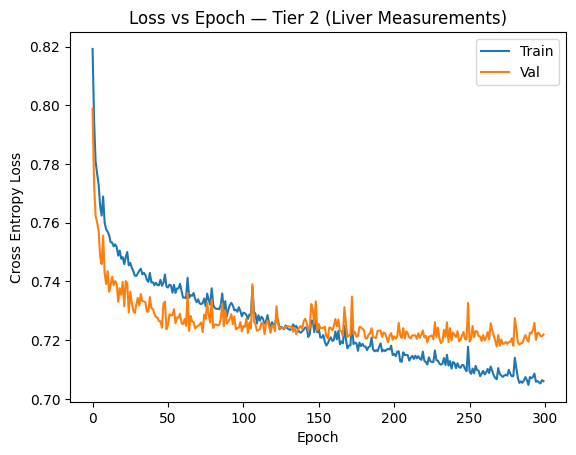

Class 0 (Healthy     ) | F1: 0.8038  AUROC: 0.8227  AUPRC: 0.8826
Class 1 (Prediabetic ) | F1: 0.3643  AUROC: 0.7256  AUPRC: 0.4171
Class 2 (Diabetic    ) | F1: 0.1928  AUROC: 0.8266  AUPRC: 0.3545

 ------- Tier 3 (Full Panel) -----------
Epoch    0 | Train Loss: 0.8346  Val Loss: 0.8394
Epoch   50 | Train Loss: 0.5841  Val Loss: 0.7562
Epoch  100 | Train Loss: 0.4400  Val Loss: 0.8716
Epoch  150 | Train Loss: 0.3075  Val Loss: 1.0310
Epoch  200 | Train Loss: 0.2148  Val Loss: 1.2839
Epoch  250 | Train Loss: 0.1037  Val Loss: 1.5124
Epoch    0 | Train Loss: 0.9657  Val Loss: 0.9602
Epoch   50 | Train Loss: 0.6937  Val Loss: 0.7443
Epoch  100 | Train Loss: 0.6520  Val Loss: 0.7410
Epoch  150 | Train Loss: 0.6159  Val Loss: 0.7490
Epoch  200 | Train Loss: 0.5794  Val Loss: 0.7627
Epoch  250 | Train Loss: 0.5422  Val Loss: 0.7866
Epoch    0 | Train Loss: 1.2110  Val Loss: 1.2256
Epoch   50 | Train Loss: 0.9315  Val Loss: 0.9262
Epoch  100 | Train Loss: 0.8650  Val Loss: 0.8650
Epoch  150

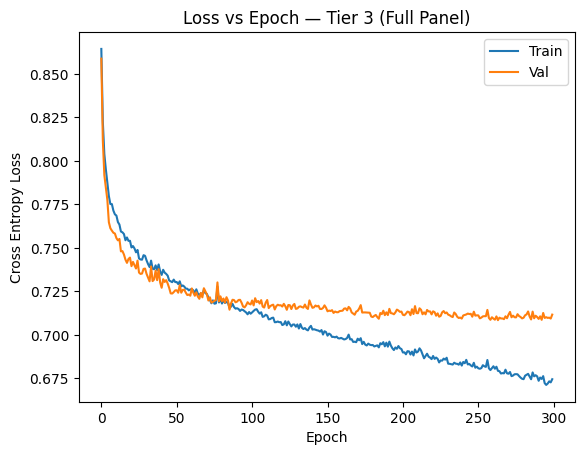

Class 0 (Healthy     ) | F1: 0.8051  AUROC: 0.8259  AUPRC: 0.8841
Class 1 (Prediabetic ) | F1: 0.3899  AUROC: 0.7313  AUPRC: 0.4393
Class 2 (Diabetic    ) | F1: 0.1988  AUROC: 0.8392  AUPRC: 0.4027


--------average across tiers--------
Class             Avg F1  Avg AUROC  Avg AUPRC
---------------------------------------------
Healthy           0.8042     0.8224     0.8811
Prediabetic       0.3836     0.7268     0.4254
Diabetic          0.2031     0.8230     0.3536


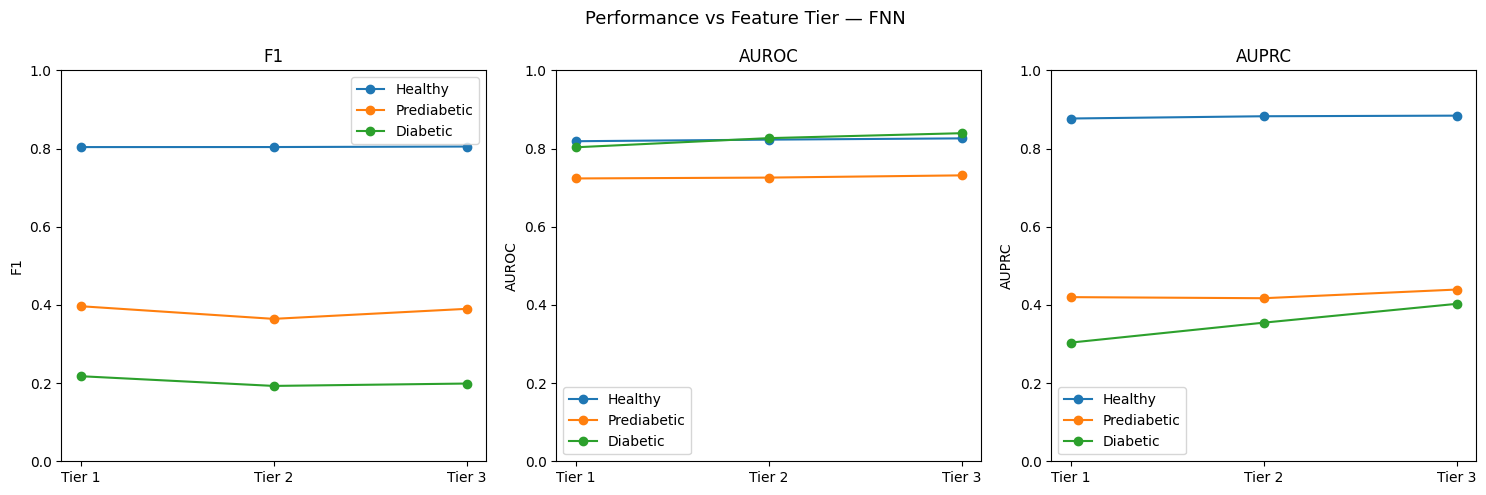

In [ ]:
from itertools import product as iterproduct

alphas      = [0.01, 0.001]
dropouts    = [0.0, 0.3]
architectures = [
    [128, 64],
    [256, 128, 64],     # deeper + wider
    [64, 32],           # shallower + narrower
]
batch_sizes = [32, 128, len(x_train)]  # mini-batch, larger batch, full-batch (GD)
n_classes  = 3
class_names = ["Healthy", "Prediabetic", "Diabetic"]
tier_results = {}

for tier_name, cols in tiers.items():
    print(f"\n ------- {tier_name} -----------")
    scaler = StandardScaler()
    X_train_tier = scaler.fit_transform(x_train[cols])
    X_test_tier  = scaler.transform(x_test[cols])
    Y_train_tier = one_hot(y_train.values, n_classes)
    Y_test_tier  = one_hot(y_test.values,  n_classes)
    n_feat = X_train_tier.shape[1]

    best_val_loss = float("inf")
    best_params   = None
    best_W, best_b = None, None
    best_train_losses, best_test_losses = None, None

    for alpha, d, arch, bs in iterproduct(alphas, dropouts, architectures, batch_sizes):
        layer_sizes = [n_feat] + arch + [n_classes]
        W, b, train_losses, test_losses = train_fnn(
            X_train_tier, Y_train_tier,
            X_test_tier,  Y_test_tier,
            layer_sizes, alpha=alpha, dropout=d,
            epochs=300, batch_size=bs
        )
        if test_losses[-1] < best_val_loss:
            best_val_loss = test_losses[-1]
            best_params   = {"alpha": alpha, "dropout": d, "arch": arch, "batch_size": bs}
            best_train_losses, best_test_losses = train_losses, test_losses
            best_W, best_b = W, b

    print(f"\nBest params: lr={best_params['alpha']}  dropout={best_params['dropout']}  "
          f"arch={best_params['arch']}  batch_size={best_params['batch_size']}")

    plt.plot(best_train_losses, label="Train")
    plt.plot(best_test_losses,  label="Val")
    plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Cross Entropy Loss")
    plt.title(f"Loss vs Epoch — {tier_name}"); plt.show()

    y_pred, y_probs = predict_fnn(X_test_tier, best_W, best_b)
    y_true = y_test.values
    f1_scores = f1_classwise(y_true, y_pred, n_classes)

    tier_results[tier_name] = {"f1": {}, "auroc": {}, "auprc": {}}
    for c in range(n_classes):
        y_true_bin = (y_true == c).astype(int)
        auroc_val, _, _ = auroc(y_true_bin, y_probs[:, c])
        auprc_val, _, _ = auprc(y_true_bin,  y_probs[:, c])
        f1_val = f1_scores[c]["f1"]
        tier_results[tier_name]["f1"][c]    = f1_val
        tier_results[tier_name]["auroc"][c] = auroc_val
        tier_results[tier_name]["auprc"][c] = auprc_val
        print(f"Class {c} ({class_names[c]:12s}) | F1: {f1_val:.4f}  AUROC: {auroc_val:.4f}  AUPRC: {auprc_val:.4f}")

print("\n\n--------average across tiers--------")
print(f"{'Class':<15} {'Avg F1':>8} {'Avg AUROC':>10} {'Avg AUPRC':>10}")
print("-" * 45)
for c, cname in enumerate(class_names):
    avg_f1    = np.mean([tier_results[t]["f1"][c]    for t in tier_results])
    avg_auroc = np.mean([tier_results[t]["auroc"][c] for t in tier_results])
    avg_auprc = np.mean([tier_results[t]["auprc"][c] for t in tier_results])
    print(f"{cname:<15} {avg_f1:>8.4f} {avg_auroc:>10.4f} {avg_auprc:>10.4f}")

tier_names = list(tier_results.keys())
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, label in zip(axes, ["f1", "auroc", "auprc"], ["F1", "AUROC", "AUPRC"]):
    for c, cname in enumerate(class_names):
        scores = [tier_results[t][metric][c] for t in tier_names]
        ax.plot(["Tier 1", "Tier 2", "Tier 3"], scores, marker="o", label=cname)
    ax.set_title(label); ax.set_ylabel(label)
    ax.legend(); ax.set_ylim(0, 1)
plt.suptitle("Performance vs Feature Tier — FNN", fontsize=13)
plt.tight_layout(); plt.show()


 ------ Tier 1 (Demographic + Vitals)-------
Epoch    0 | Train Loss: 0.8007  Val Loss: 0.7762
Epoch   50 | Train Loss: 0.7546  Val Loss: 0.7426
Epoch  100 | Train Loss: 0.7461  Val Loss: 0.7396
Epoch  150 | Train Loss: 0.7447  Val Loss: 0.7390
Epoch  200 | Train Loss: 0.7428  Val Loss: 0.7403
Epoch  250 | Train Loss: 0.7415  Val Loss: 0.7376


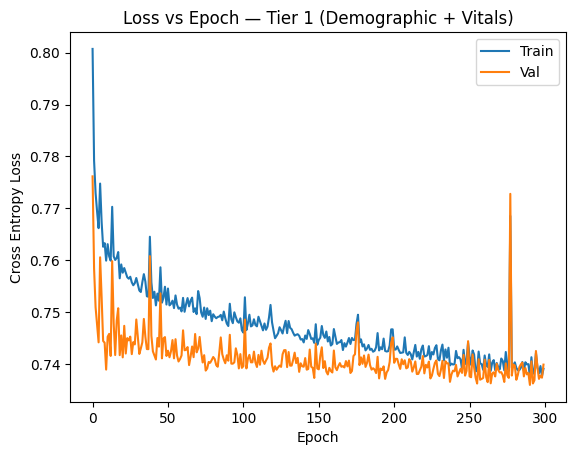

Class 0 (Healthy     ) | F1: 0.7963  AUROC: 0.8154  AUPRC: 0.8775
Class 1 (Prediabetic ) | F1: 0.3059  AUROC: 0.7215  AUPRC: 0.4218
Class 2 (Diabetic    ) | F1: 0.1375  AUROC: 0.8017  AUPRC: 0.2925

 ------ Tier 2 (Liver Measurements)-------
Epoch    0 | Train Loss: 0.8192  Val Loss: 0.7988
Epoch   50 | Train Loss: 0.7379  Val Loss: 0.7252
Epoch  100 | Train Loss: 0.7294  Val Loss: 0.7248
Epoch  150 | Train Loss: 0.7239  Val Loss: 0.7255
Epoch  200 | Train Loss: 0.7154  Val Loss: 0.7214
Epoch  250 | Train Loss: 0.7094  Val Loss: 0.7195


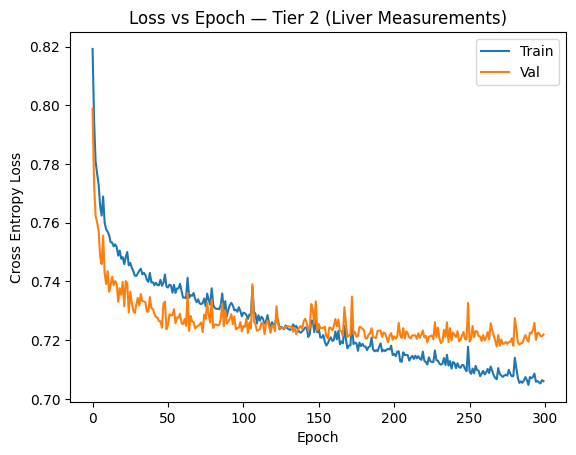

Class 0 (Healthy     ) | F1: 0.8038  AUROC: 0.8227  AUPRC: 0.8826
Class 1 (Prediabetic ) | F1: 0.3643  AUROC: 0.7256  AUPRC: 0.4171
Class 2 (Diabetic    ) | F1: 0.1928  AUROC: 0.8266  AUPRC: 0.3545

 ------ Tier 3 (Full Panel)-------
Epoch    0 | Train Loss: 0.8644  Val Loss: 0.8588
Epoch   50 | Train Loss: 0.7303  Val Loss: 0.7256
Epoch  100 | Train Loss: 0.7129  Val Loss: 0.7197
Epoch  150 | Train Loss: 0.6995  Val Loss: 0.7135
Epoch  200 | Train Loss: 0.6898  Val Loss: 0.7115
Epoch  250 | Train Loss: 0.6807  Val Loss: 0.7112


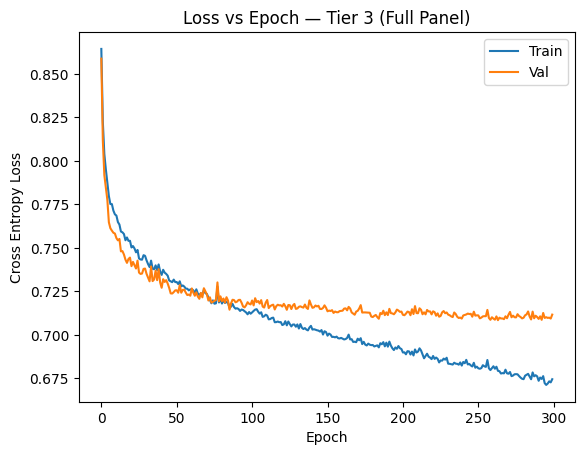

Class 0 (Healthy     ) | F1: 0.8051  AUROC: 0.8259  AUPRC: 0.8841
Class 1 (Prediabetic ) | F1: 0.3899  AUROC: 0.7313  AUPRC: 0.4393
Class 2 (Diabetic    ) | F1: 0.1988  AUROC: 0.8392  AUPRC: 0.4027


--------average across tiers--------
Class             Avg F1  Avg AUROC  Avg AUPRC
---------------------------------------------
Healthy           0.8017     0.8214     0.8814
Prediabetic       0.3534     0.7262     0.4261
Diabetic          0.1764     0.8225     0.3499


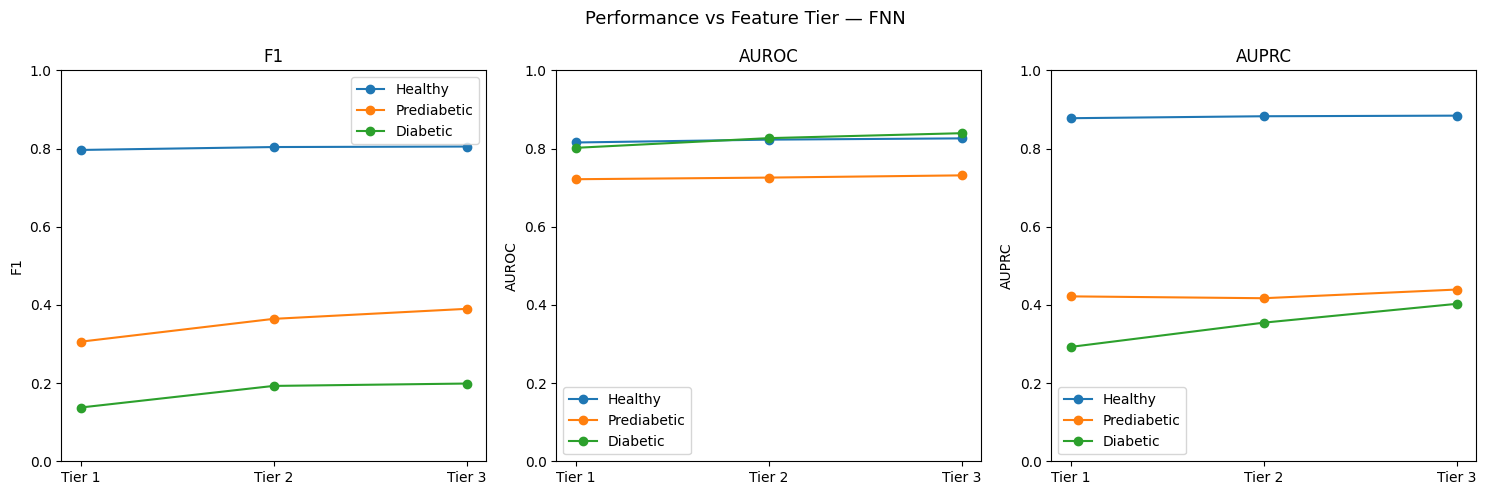

In [20]:
n_classes = 3
class_names = ["Healthy", "Prediabetic", "Diabetic"]
tier_results = {}
opt_param = {"alpha": 0.01, "dropout":0.3, "arch": [128, 64], "batch_size":32}
for tier_name, cols in tiers.items():
  print(f"\n ------ {tier_name}-------")
  scalar = StandardScaler()
  X_train_tier = scalar.fit_transform(x_train[cols])
  X_test_tier = scalar.transform(x_test[cols])
  Y_train_tier = one_hot(y_train.values, n_classes)
  Y_test_tier = one_hot(y_test.values, n_classes)
  n_feat = X_train_tier.shape[1]
  layer_sizes = [n_feat] + opt_param["arch"] + [n_classes]
  W, b, train_losses, test_losses = train_fnn(
      X_train_tier, Y_train_tier,
      X_test_tier,  Y_test_tier,
      layer_sizes, alpha = opt_param["alpha"], dropout = opt_param["dropout"],
      epochs = 300, batch_size = opt_param["batch_size"]
  )
  plt.plot(train_losses, label="Train")
  plt.plot(test_losses,  label="Val")
  plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Cross Entropy Loss")
  plt.title(f"Loss vs Epoch — {tier_name}"); plt.show()

  y_pred, y_probs = predict_fnn(X_test_tier, W, b)
  y_true = y_test.values
  f1_scores = f1_classwise(y_true, y_pred, n_classes)

  tier_results[tier_name] = {"f1": {}, "auroc": {}, "auprc": {}}
  for c in range(n_classes):
      y_true_bin = (y_true == c).astype(int)
      auroc_val, _, _ = auroc(y_true_bin, y_probs[:, c])
      auprc_val, _, _ = auprc(y_true_bin,  y_probs[:, c])
      f1_val = f1_scores[c]["f1"]
      tier_results[tier_name]["f1"][c]    = f1_val
      tier_results[tier_name]["auroc"][c] = auroc_val
      tier_results[tier_name]["auprc"][c] = auprc_val
      print(f"Class {c} ({class_names[c]:12s}) | F1: {f1_val:.4f}  AUROC: {auroc_val:.4f}  AUPRC: {auprc_val:.4f}")

print("\n\n--------average across tiers--------")
print(f"{'Class':<15} {'Avg F1':>8} {'Avg AUROC':>10} {'Avg AUPRC':>10}")
print("-" * 45)
for c, cname in enumerate(class_names):
    avg_f1    = np.mean([tier_results[t]["f1"][c]    for t in tier_results])
    avg_auroc = np.mean([tier_results[t]["auroc"][c] for t in tier_results])
    avg_auprc = np.mean([tier_results[t]["auprc"][c] for t in tier_results])
    print(f"{cname:<15} {avg_f1:>8.4f} {avg_auroc:>10.4f} {avg_auprc:>10.4f}")

tier_names = list(tier_results.keys())
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, label in zip(axes, ["f1", "auroc", "auprc"], ["F1", "AUROC", "AUPRC"]):
    for c, cname in enumerate(class_names):
        scores = [tier_results[t][metric][c] for t in tier_names]
        ax.plot(["Tier 1", "Tier 2", "Tier 3"], scores, marker="o", label=cname)
    ax.set_title(label); ax.set_ylabel(label)
    ax.legend(); ax.set_ylim(0, 1)
plt.suptitle("Performance vs Feature Tier — FNN", fontsize=13)
plt.tight_layout(); plt.show()